# Chapter 4 — Linear Transformations and Matrix Algebra

Numerical companion to `notes.md`. We'll:

1. Check linearity of a candidate function numerically and build its **standard matrix** from `T(e_i)`.
2. Visualize the 2D catalog — rotation, reflection, scaling, shear, projection — as transformations of the unit square.
3. Animate a rotation through a sequence of angles.
4. See matrix multiplication *as composition*: apply `B` then `A`, and compare with `A B`.
5. Invert a matrix both by the `2 × 2` formula and by augmenting with `I` and running Gauss–Jordan — and watch non-invertibility appear when the columns collapse onto a line.
6. Verify `(A B)^{-1} = B^{-1} A^{-1}` (socks and shoes).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. Check linearity by random sampling

Given a candidate `T: ℝ² → ℝ²`, we verify both laws at many random inputs:

- **Additivity:** `T(u + v) == T(u) + T(v)`
- **Homogeneity:** `T(c · u) == c · T(u)`

If either fails on *any* sample, the map isn't linear. (Passing on samples doesn't prove linearity — but for "pick a formula and check," it's a strong signal.)

In [2]:
def check_linearity(T, n_in=2, trials=200, tol=1e-10):
    for _ in range(trials):
        u = rng.normal(size=n_in)
        v = rng.normal(size=n_in)
        c = rng.normal()
        if np.max(np.abs(T(u + v) - (T(u) + T(v)))) > tol:
            return False, 'additivity failed'
        if np.max(np.abs(T(c * u) - c * T(u))) > tol:
            return False, 'homogeneity failed'
    return True, 'passed'

# Candidate 1 — linear
T1 = lambda v: np.array([3 * v[0] - v[1], 2 * v[0] + 5 * v[1]])
print('T(x,y) = (3x - y, 2x + 5y)      ->', check_linearity(T1))

# Candidate 2 — not linear (constant shift)
T2 = lambda v: np.array([v[0] + 1, v[1]])
print('T(x,y) = (x + 1, y)             ->', check_linearity(T2))

# Candidate 3 — not linear (product term)
T3 = lambda v: np.array([v[0] * v[1], v[0]])
print('T(x,y) = (xy, x)                ->', check_linearity(T3))

T(x,y) = (3x - y, 2x + 5y)      -> (True, 'passed')
T(x,y) = (x + 1, y)             -> (False, 'additivity failed')
T(x,y) = (xy, x)                -> (False, 'additivity failed')


## 2. Build the standard matrix

From §4.4: the columns of `A` are `T(e_1), T(e_2), …, T(e_n)`.

In [3]:
def standard_matrix(T, n_in):
    cols = [T(np.eye(n_in)[:, j]) for j in range(n_in)]
    return np.column_stack(cols)

A1 = standard_matrix(T1, 2)
print('Standard matrix of T1:')
print(A1)

# Cross-check: A1 @ [4, 7] should equal T1([4, 7])
v = np.array([4.0, 7.0])
print('\nA @ v  =', A1 @ v)
print('T1(v)  =', T1(v))

Standard matrix of T1:
[[ 3. -1.]
 [ 2.  5.]]

A @ v  = [ 5. 43.]
T1(v)  = [ 5. 43.]


## 3. The 2D geometric catalog

For each matrix `A`, draw where the unit square goes. The unit square has corners `(0,0), (1,0), (1,1), (0,1)`. Its image under `x ↦ Ax` is a parallelogram (possibly degenerate).

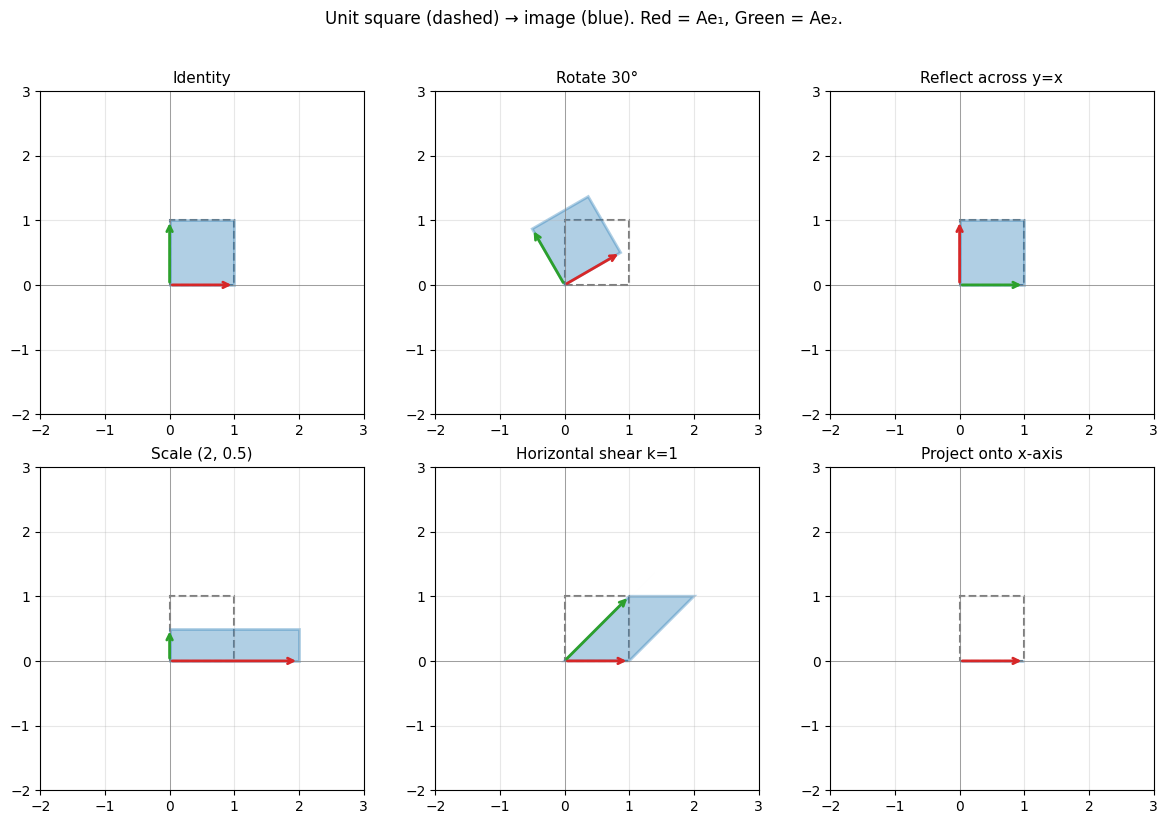

In [4]:
unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]]).T   # 2 × 4

theta = np.pi / 6   # 30 degrees

catalog = {
    'Identity':            np.array([[1, 0], [0, 1]], dtype=float),
    'Rotate 30°':          np.array([[np.cos(theta), -np.sin(theta)],
                                     [np.sin(theta),  np.cos(theta)]]),
    'Reflect across y=x':  np.array([[0, 1], [1, 0]], dtype=float),
    'Scale (2, 0.5)':      np.array([[2, 0], [0, 0.5]], dtype=float),
    'Horizontal shear k=1':np.array([[1, 1], [0, 1]], dtype=float),
    'Project onto x-axis': np.array([[1, 0], [0, 0]], dtype=float),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, A) in zip(axes.flat, catalog.items()):
    # Original square — dashed gray
    orig = Polygon(unit_square.T, closed=True, fill=False,
                   linestyle='--', edgecolor='gray', lw=1.5)
    ax.add_patch(orig)
    # Transformed
    img = A @ unit_square
    tp = Polygon(img.T, closed=True, fill=True,
                 facecolor='tab:blue', alpha=0.35,
                 edgecolor='tab:blue', lw=2)
    ax.add_patch(tp)
    # Column vectors (images of e1, e2)
    for col, color in zip(A.T, ['tab:red', 'tab:green']):
        ax.annotate('', xy=col, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-2, 3); ax.set_ylim(-2, 3)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(name, fontsize=11)

plt.suptitle('Unit square (dashed) → image (blue). Red = Ae₁, Green = Ae₂.',
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## 4. Animating a rotation

Build the rotation matrix `R(θ)` and watch the unit square swing through a range of angles.

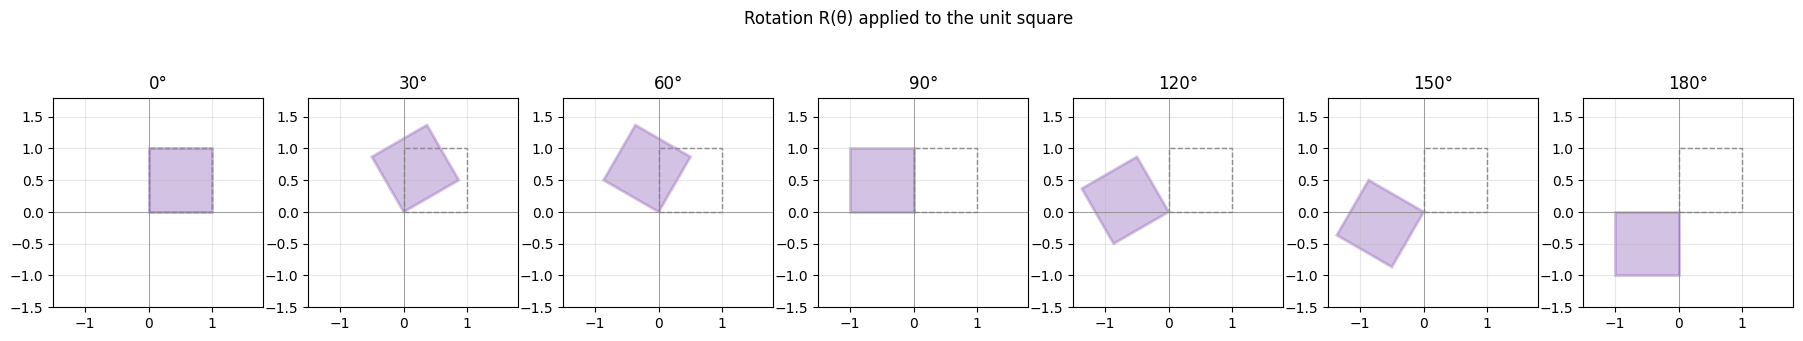

In [5]:
def R(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

angles_deg = [0, 30, 60, 90, 120, 150, 180]
fig, axes = plt.subplots(1, len(angles_deg), figsize=(18, 3.2))
for ax, ang in zip(axes, angles_deg):
    A = R(np.deg2rad(ang))
    orig = Polygon(unit_square.T, closed=True, fill=False,
                   linestyle='--', edgecolor='gray', lw=1)
    ax.add_patch(orig)
    img = A @ unit_square
    ax.add_patch(Polygon(img.T, closed=True, fill=True,
                         facecolor='tab:purple', alpha=0.4,
                         edgecolor='tab:purple', lw=2))
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-1.5, 1.8); ax.set_ylim(-1.5, 1.8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(f'{ang}°')

plt.suptitle('Rotation R(θ) applied to the unit square', y=1.05)
plt.tight_layout(); plt.show()

## 5. Composition = matrix multiplication, and it's not commutative

Pick `A` = rotate 90°, `B` = horizontal shear by 1. Compare `AB` (first shear, then rotate) with `BA` (first rotate, then shear).

In [6]:
A = R(np.pi / 2)                   # rotation 90° anticlockwise
B = np.array([[1, 1], [0, 1]], float)  # horizontal shear

AB = A @ B
BA = B @ A
print('A (rotate 90°):')
print(A)
print('\nB (shear right 1):')
print(B)
print('\nAB  (first B, then A):')
print(AB)
print('\nBA  (first A, then B):')
print(BA)
print('\nA B - B A =\n', AB - BA, '   -> clearly nonzero')

A (rotate 90°):
[[ 0. -1.]
 [ 1.  0.]]

B (shear right 1):
[[1. 1.]
 [0. 1.]]

AB  (first B, then A):
[[ 0. -1.]
 [ 1.  1.]]

BA  (first A, then B):
[[ 1. -1.]
 [ 1.  0.]]

A B - B A =
 [[-1.  0.]
 [ 0.  1.]]    -> clearly nonzero


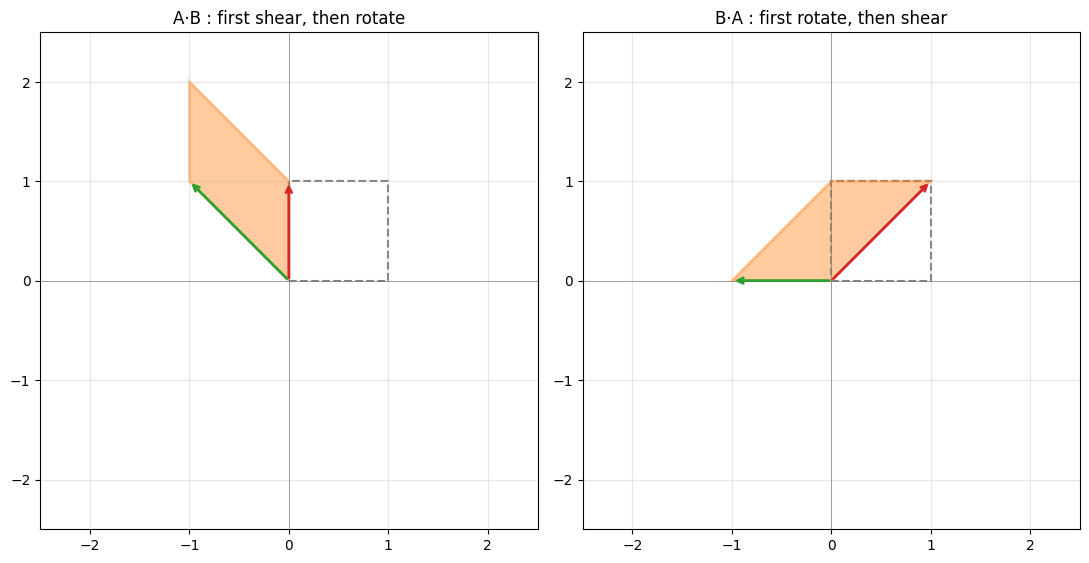

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (label, M) in zip(axes, [('A·B : first shear, then rotate', AB),
                                   ('B·A : first rotate, then shear', BA)]):
    orig = Polygon(unit_square.T, closed=True, fill=False,
                   linestyle='--', edgecolor='gray', lw=1.5)
    ax.add_patch(orig)
    img = M @ unit_square
    ax.add_patch(Polygon(img.T, closed=True, fill=True,
                         facecolor='tab:orange', alpha=0.4,
                         edgecolor='tab:orange', lw=2))
    for col, color in zip(M.T, ['tab:red', 'tab:green']):
        ax.annotate('', xy=col, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(label)
plt.tight_layout(); plt.show()

## 6. Associativity and distributivity — numerical check

The matrix algebra rules from §4.7.3. Random matrices, random verification.

In [8]:
M1 = rng.normal(size=(3, 3))
M2 = rng.normal(size=(3, 3))
M3 = rng.normal(size=(3, 3))

# Associativity
lhs = (M1 @ M2) @ M3
rhs =  M1 @ (M2 @ M3)
print('max |(AB)C - A(BC)| =', np.max(np.abs(lhs - rhs)))

# Left-distributivity
lhs = M1 @ (M2 + M3)
rhs =  M1 @ M2 + M1 @ M3
print('max |A(B+C) - AB - AC| =', np.max(np.abs(lhs - rhs)))

# (AB)^T = B^T A^T
lhs = (M1 @ M2).T
rhs =  M2.T @ M1.T
print('max |(AB)^T - B^T A^T| =', np.max(np.abs(lhs - rhs)))

max |(AB)C - A(BC)| = 8.881784197001252e-16
max |A(B+C) - AB - AC| = 8.881784197001252e-16
max |(AB)^T - B^T A^T| = 0.0


## 7. The `2 × 2` inverse formula

For `A = [[a, b], [c, d]]`, if `det A = ad - bc ≠ 0`, then

```
A^{-1} = (1 / (ad - bc)) · [[ d, -b], [-c,  a]]
```

In [9]:
def inv_2x2(A):
    a, b = A[0]; c, d = A[1]
    det = a * d - b * c
    if abs(det) < 1e-12:
        raise ValueError('singular')
    return (1.0 / det) * np.array([[d, -b], [-c, a]])

S = np.array([[2, 5], [1, 3]], float)
S_inv = inv_2x2(S)
print('S =\n', S)
print('S^{-1} =\n', S_inv)
print('S @ S^{-1} =\n', S @ S_inv)

S =
 [[2. 5.]
 [1. 3.]]
S^{-1} =
 [[ 3. -5.]
 [-1.  2.]]
S @ S^{-1} =
 [[1. 0.]
 [0. 1.]]


## 8. General inverse via Gauss–Jordan on `[A | I]`

Apply EROs until the left block is `I`. Whatever the right block becomes is `A^{-1}`. This reuses the `rref` helper style from Chapter 3.

In [10]:
def rref(M, tol=1e-10):
    A = M.astype(float).copy()
    m, n = A.shape
    pivot_row = 0
    for col in range(n):
        if pivot_row >= m:
            break
        sub = np.abs(A[pivot_row:, col])
        rel = int(np.argmax(sub))
        if sub[rel] < tol:
            continue
        target = pivot_row + rel
        if target != pivot_row:
            A[[pivot_row, target]] = A[[target, pivot_row]]
        A[pivot_row] = A[pivot_row] / A[pivot_row, col]
        for r in range(m):
            if r != pivot_row and abs(A[r, col]) > tol:
                A[r] = A[r] - A[r, col] * A[pivot_row]
        pivot_row += 1
    return A

def invert_via_gj(A):
    A = np.asarray(A, float)
    n = A.shape[0]
    assert A.shape == (n, n), 'matrix must be square'
    aug = np.hstack([A, np.eye(n)])
    R = rref(aug)
    left, right = R[:, :n], R[:, n:]
    if not np.allclose(left, np.eye(n), atol=1e-8):
        raise ValueError('matrix is singular — left block did not reduce to I')
    return right

A = np.array([[1, 0, 2],
              [2, 1, 3],
              [1, 0, 1]], float)
Ainv = invert_via_gj(A)
print('A^{-1} via Gauss-Jordan:')
print(Ainv)
print('\nCompare numpy.linalg.inv:')
print(np.linalg.inv(A))
print('\nA @ A^{-1} =\n', A @ Ainv)

A^{-1} via Gauss-Jordan:
[[-1.  0.  2.]
 [-1.  1. -1.]
 [ 1. -0. -1.]]

Compare numpy.linalg.inv:
[[-1.  0.  2.]
 [-1.  1. -1.]
 [ 1. -0. -1.]]

A @ A^{-1} =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 9. Non-invertible matrices — columns on a single line

A `2 × 2` matrix whose two columns are parallel has determinant zero. Geometrically, the image of the whole plane collapses onto a single line through the origin — information is lost, and no inverse exists.

det P = 0.0


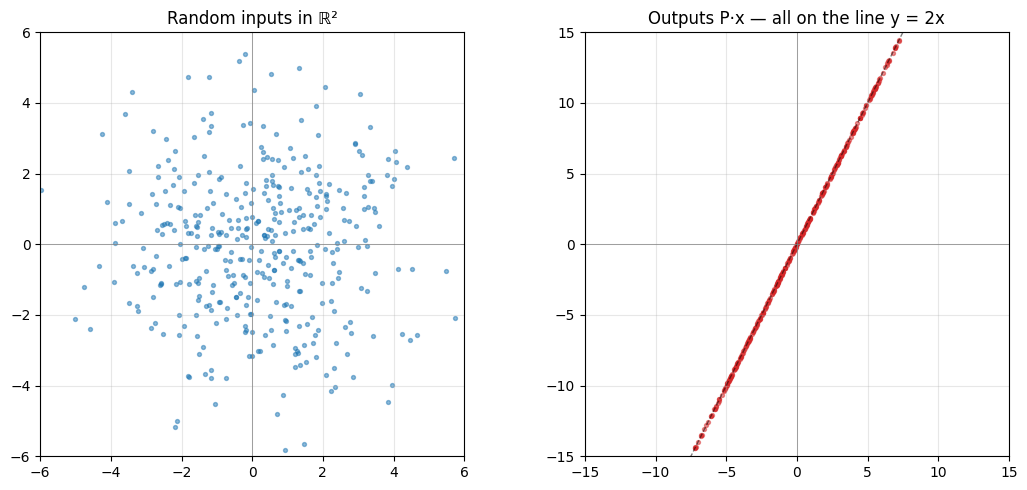

As expected, inv_2x2(P) raises: singular


In [11]:
P = np.array([[1, 2], [2, 4]], float)   # columns (1,2) and (2,4) = 2·(1,2)
print('det P =', np.linalg.det(P))

# Sample many random inputs, plot where P sends them
pts = rng.normal(size=(2, 400)) * 2
out = P @ pts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.scatter(pts[0], pts[1], s=8, alpha=0.5, color='tab:blue')
ax1.axhline(0, color='gray', lw=0.5); ax1.axvline(0, color='gray', lw=0.5)
ax1.set_aspect('equal'); ax1.grid(alpha=0.3)
ax1.set_title('Random inputs in ℝ²')
ax1.set_xlim(-6, 6); ax1.set_ylim(-6, 6)

ax2.scatter(out[0], out[1], s=8, alpha=0.5, color='tab:red')
# plot the line y = 2x (the column space of P)
xx = np.linspace(-15, 15, 100); ax2.plot(xx, 2 * xx, 'k--', alpha=0.5, lw=1)
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
ax2.set_aspect('equal'); ax2.grid(alpha=0.3)
ax2.set_title('Outputs P·x — all on the line y = 2x')
ax2.set_xlim(-15, 15); ax2.set_ylim(-15, 15)
plt.tight_layout(); plt.show()

try:
    inv_2x2(P)
except ValueError as e:
    print('As expected, inv_2x2(P) raises:', e)

## 10. Inverse of a product — socks and shoes

Numerical verification of `(A B)^{-1} = B^{-1} A^{-1}`. And the *wrong* order `A^{-1} B^{-1}` gives a different matrix.

In [12]:
A = rng.normal(size=(4, 4))
B = rng.normal(size=(4, 4))

AB_inv = np.linalg.inv(A @ B)

correct = np.linalg.inv(B) @ np.linalg.inv(A)   # B^-1 A^-1
wrong   = np.linalg.inv(A) @ np.linalg.inv(B)   # A^-1 B^-1

print('max |(AB)^{-1} - B^{-1} A^{-1}| =', np.max(np.abs(AB_inv - correct)))
print('max |(AB)^{-1} - A^{-1} B^{-1}| =', np.max(np.abs(AB_inv - wrong)),
      '  <- usually large, confirming order matters')

max |(AB)^{-1} - B^{-1} A^{-1}| = 5.551115123125783e-16
max |(AB)^{-1} - A^{-1} B^{-1}| = 2.4150878710075485   <- usually large, confirming order matters


## 11. Mini-project — find `A` from two input/output pairs

Given `T(1, 0) = (2, 3)` and `T(1, 1) = (5, 7)` (Exercise E9), recover the standard matrix `A`.

Method: write the knowns as the matrix equation `A · X = Y`, where `X` has the input column vectors stacked and `Y` has the outputs. Solve `A = Y · X^{-1}`.

In [13]:
X = np.array([[1, 1], [0, 1]], float)   # columns are (1,0) and (1,1)
Y = np.array([[2, 5], [3, 7]], float)   # columns are T(1,0) and T(1,1)

A = Y @ np.linalg.inv(X)
print('Recovered A =')
print(A)

# Spot-check
print('\nA @ (1, 0) =', A @ np.array([1, 0]), '  should be (2, 3)')
print('A @ (1, 1) =', A @ np.array([1, 1]), '  should be (5, 7)')
# And T(e2)?  Since e2 = (1,1) - (1,0):
print('A @ e2     =', A @ np.array([0, 1]), '  should be (3, 4) per E9')

Recovered A =
[[2. 3.]
 [3. 4.]]

A @ (1, 0) = [2. 3.]   should be (2, 3)
A @ (1, 1) = [5. 7.]   should be (5, 7)
A @ e2     = [3. 4.]   should be (3, 4) per E9


## Takeaways

- **Every linear map ↔ a matrix**, via `A = [T(e_1) | … | T(e_n)]`. Geometry and algebra are two views of the same object.
- **The `2 × 2` catalog** is worth knowing cold: rotations, reflections, shears, scalings, projections — each a 4-number matrix.
- **Matrix multiplication = composition**, which is why it's associative (function composition is) but *not* commutative in general.
- **Invertibility** fails exactly when columns are linearly dependent — the map collapses onto a lower-dimensional image.
- Gauss–Jordan on `[A | I]` gives an honest algorithm for `A^{-1}`; the `2 × 2` formula is a shortcut for a common case.